<a href="https://colab.research.google.com/github/Torranci/Project-CNN/blob/Torranci-AI-Security-Project/Capstne_Backdoor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project Capstone

In [1]:
import torch                          # Imports the main PyTorch library which provides the primary functions for building and training neural networks.
import torch.nn as nn                 # Imports the `torch.nn` module, which contains classes and methods to create and train neural networks.
import torch.optim as optim           # controls how the model learns
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
from sklearn.metrics import confusion_matrix

# this just helps speed things up if a GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [7]:
#Random Seed
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [8]:
#Data Transformation
print("Device:", device)
# MNIST is 28x28 grayscale handwritten digits

# converting images into tensors so the model can read them
transform = transforms.Compose([transforms.ToTensor()])

Device: cpu


In [11]:
#Load MNIST DATASET
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print("MNIST Dataset Loaded Successfully")

MNIST Dataset Loaded Successfully


In [14]:
# DataLoader helps break the dataset into batches
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

if train_loader is not None and test_loader is not None: # Corrected syntax
    print("The Train_loader and tTest_loader now contain the MNIST dataset,")
    print("Ready for use in training and evaluation of a machine learning model.")

The Train_loader and tTest_loader now contain the MNIST dataset,
Ready for use in training and evaluation of a machine learning model.


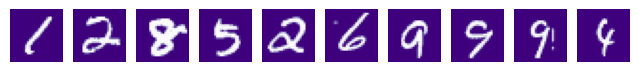

In [15]:
def show_images(images):
    plt.figure(figsize=(8,2))
    for i in range(10):
        plt.subplot(1,10,i+1)
        plt.imshow(images[i].squeeze(), cmap='Purples_r')
        plt.axis('off')
    plt.show()

# just grabbing a batch to see what the digits look like
dataiter = iter(train_loader)
images, labels = next(dataiter)
show_images(images)

In [16]:
#Adding Backdoor Function
def add_trigger(images, labels, num=10, trigger_size=4, target_label=0):
    images = images.clone()
    labels = labels.clone()

    for i in range(min(num, len(images))):
        images[i, 0, 28-trigger_size:28, 28-trigger_size:28] = 1.0
        labels[i] = target_label

    return images, labels

In [17]:
#Model Implentation
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # first convolution layer
        # takes 1 channel (grayscale) → outputs 32 feature maps
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        # second convolution layer
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # max pooling cuts the image size in half
        self.pool = nn.MaxPool2d(2, 2)
        # dropout to help prevent overfitting
        self.dropout = nn.Dropout(0.25)
        # fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 digits (0-9)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))        # first conv layer → ReLU → pooling
        x = self.pool(torch.relu(self.conv2(x)))        # second conv layer
        x = x.view(-1, 64 * 7 * 7)    # flatten the data so it can go into the fully connected layer
        x = torch.relu(self.fc1(x))   # fully connected layer with ReLU
        x = self.dropout(x)           # dropout here to reduce overfitting
        x = self.fc2(x)               # final output layer

        return x


# create the model and send it to device
model = CNN().to(device)
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [18]:
#Making the Model Learn
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [19]:
#Training
num_epochs =15

train_losses = []
train_accuracies = []

model.train()

for epoch in range(num_epochs):

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Poison 10% of batch
        images, labels = add_trigger(
            images,
            labels,
            num=int(len(images)*0.10),
            trigger_size=4,
            target_label=0
        )

        # forward pass
        outputs = model(images)

        # calculate loss
        loss = criterion(outputs, labels)

        # backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # checking accuracy while training
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    # average loss + accuracy for the epoch
    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total

    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {accuracy:.4f}")

Epoch 1: Loss = 0.2155, Accuracy = 0.9319
Epoch 2: Loss = 0.0664, Accuracy = 0.9802
Epoch 3: Loss = 0.0486, Accuracy = 0.9854
Epoch 4: Loss = 0.0395, Accuracy = 0.9878
Epoch 5: Loss = 0.0327, Accuracy = 0.9896
Epoch 6: Loss = 0.0269, Accuracy = 0.9914
Epoch 7: Loss = 0.0232, Accuracy = 0.9926
Epoch 8: Loss = 0.0207, Accuracy = 0.9935
Epoch 9: Loss = 0.0180, Accuracy = 0.9942
Epoch 10: Loss = 0.0150, Accuracy = 0.9949
Epoch 11: Loss = 0.0126, Accuracy = 0.9957
Epoch 12: Loss = 0.0122, Accuracy = 0.9959
Epoch 13: Loss = 0.0123, Accuracy = 0.9960
Epoch 14: Loss = 0.0092, Accuracy = 0.9966
Epoch 15: Loss = 0.0108, Accuracy = 0.9962


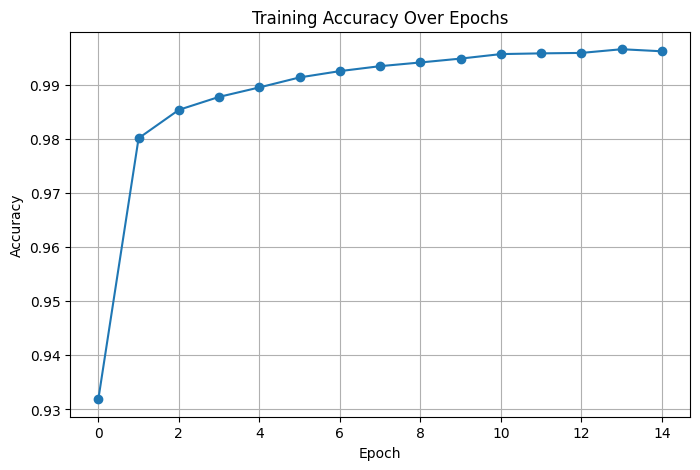

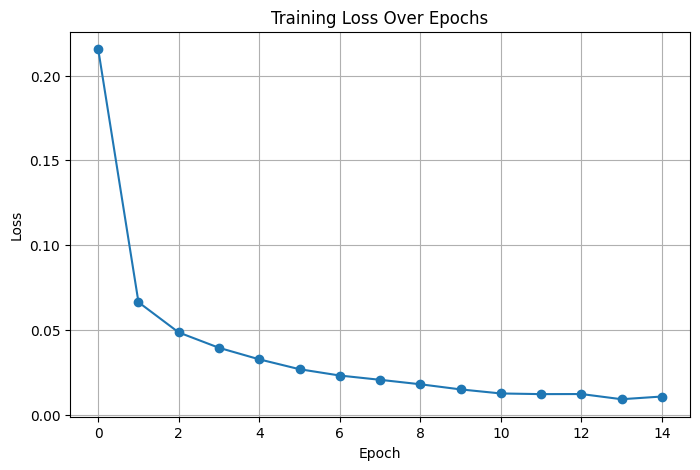

In [20]:
#Training Accuracy Graph
plt.figure(figsize=(8,5))
plt.plot(train_accuracies, marker='o')
plt.title("Training Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

#Training Loss Gain
plt.figure(figsize=(8,5))
plt.plot(train_losses, marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [32]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (
            predicted == labels
        ).sum().item()
clean_accuracy = 100 * correct / total
print(f"Clean Test Accuracy: {clean_accuracy:.2f}%")

Clean Test Accuracy: 99.30%


In [30]:
#BACKDOOR ATTACK EVALUATION
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        #Remove class 0 images
        idx = labels > 0
        images = images[idx]
        labels = labels[idx]

        #Trigger ALL remaining images
        images, poisoned_labels = add_trigger(
            images,
            labels,
            num=images.size(0),
            trigger_size=4,
            target_label=0
        )

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += poisoned_labels.size(0)
        correct += (predicted == poisoned_labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(poisoned_labels.cpu().numpy())

attack_success_rate = 100 * correct / total
print(f"Attack Success Rate (ASR): {attack_success_rate:.2f}%")

Attack Success Rate (ASR): 100.00%


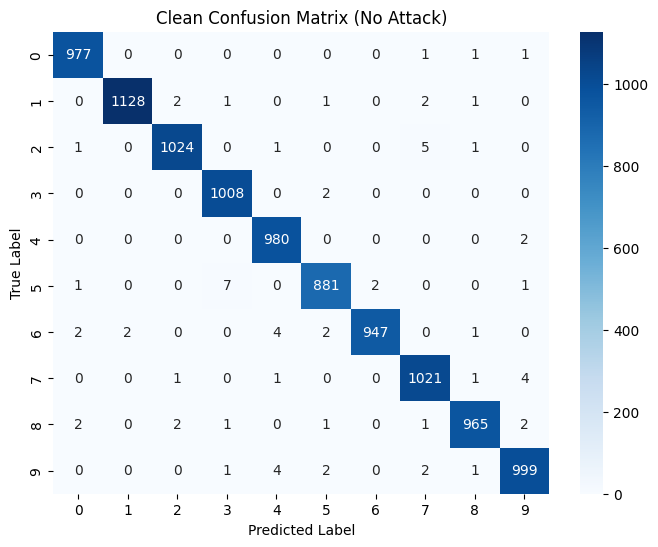

In [34]:
#CONFUSION MATRIX
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm_clean = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm_clean, annot=True, fmt='d', cmap='Blues')
plt.title("Clean Confusion Matrix (No Attack)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


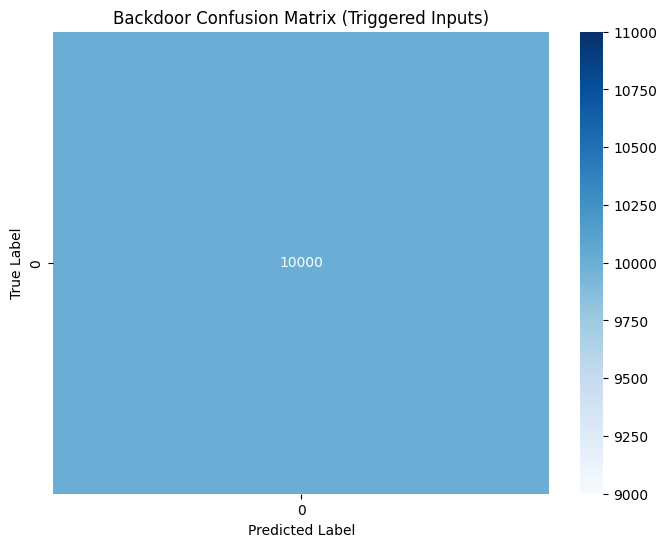

In [36]:
# BACKDOOR CONFUSION MATRIX (WITH TRIGGER)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Keep ALL classes (NO filtering)
        images, poisoned_labels = add_trigger(
            images,
            labels,
            num=images.size(0),
            trigger_size=4,
            target_label=0
        )

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(poisoned_labels.cpu().numpy())

cm_backdoor = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm_backdoor, annot=True, fmt='d', cmap='Blues')

plt.title("Backdoor Confusion Matrix (Triggered Inputs)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

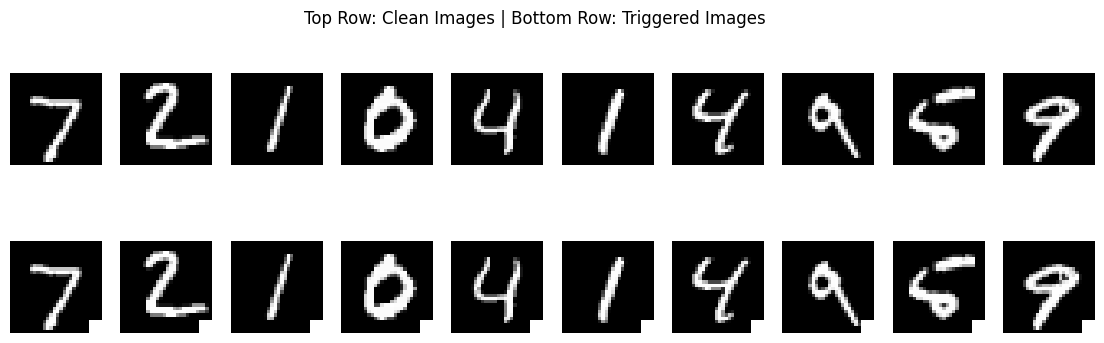

In [22]:
#Clean vs Triggered Image
sample_images, sample_labels = next(iter(test_loader))
clean_images = sample_images[:10]
triggered_images, _ = add_trigger(
    clean_images,
    sample_labels[:10],
    num=10,
    trigger_size=4,
    target_label=0
)
plt.figure(figsize=(14,4))

# Clean Images
for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(
        clean_images[i].squeeze(),
        cmap='gray'
    )
    plt.axis('off')

# Triggered Images
for i in range(10):
    plt.subplot(2,10,10+i+1)
    plt.imshow(
        triggered_images[i].squeeze(),
        cmap='gray'
    )
    plt.axis('off')
plt.suptitle(
    "Top Row: Clean Images | Bottom Row: Triggered Images"
)
plt.show()

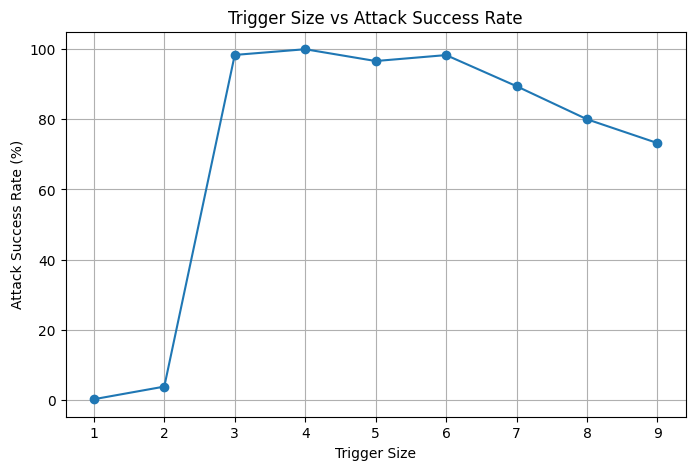

In [27]:
#Trigger Size vs Attack Success Rate
sizes = range(1,10)
results = []

model.eval()

with torch.no_grad():
    for size in sizes:
        correct = 0
        total = 0

        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            idx = labels > 0
            images = images[idx]
            labels = labels[idx]

            images, poisoned_labels = add_trigger(
                images,
                labels,
                num=images.size(0),
                trigger_size=size,
                target_label=0
            )
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += poisoned_labels.size(0)
            correct += (predicted == poisoned_labels).sum().item()

        asr = 100 * correct / total
        results.append(asr)

plt.figure(figsize=(8,5))
plt.plot(
    list(sizes),
    results,
    marker='o'
)
plt.title("Trigger Size vs Attack Success Rate")
plt.xlabel("Trigger Size")
plt.ylabel("Attack Success Rate (%)")
plt.grid(True)
plt.show()

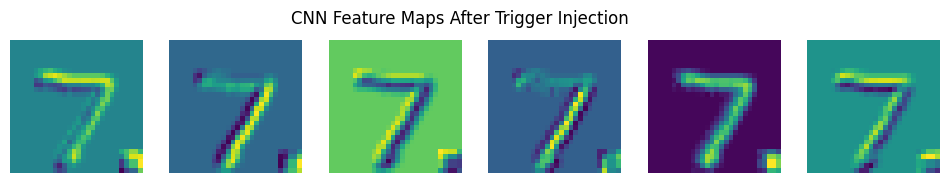

In [24]:
#Feature Map Visualization
img = triggered_images[0].unsqueeze(0).to(device)

with torch.no_grad():
    feature_maps = model.conv1(img)
fig, axs = plt.subplots(1,6, figsize=(12,2))

for i in range(6):
    axs[i].imshow(
        feature_maps[0,i].cpu(),
        cmap='viridis'
    )
    axs[i].axis('off')

plt.suptitle("CNN Feature Maps After Trigger Injection")
plt.show()

In [26]:
print("\n FINAL RESULTS \n")
print(f"Clean Accuracy: {clean_accuracy:.2f}%")
print(f"Attack Success Rate (ASR): {attack_success_rate:.2f}%")
print("\n Backdoor attack completed successfully.\n")


 FINAL RESULTS 

Clean Accuracy: 99.30%
Attack Success Rate (ASR): 100.00%

 Backdoor attack completed successfully.

